In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

In [3]:
data = pd.read_csv('electricity_theft.csv')

In [4]:
data.head()

,Consumer_ID,Meter_Age_Years,Avg_Monthly_Units,Peak_Units,OffPeak_Units,Voltage,Current,Power_Factor,Meter_Reading_Gap,Tamper_Events,Night_Usage_Ratio,Load_Variation,Theft
0,1001,7,231.83,310.87,114.25,212.69,1.58,0.886,2.43,0,0.210,0.252,0
1,1002,20,116.08,145.43,83.63,227.37,1.00,0.857,4.28,0,0.101,0.184,1
2,1003,29,136.83,165.66,60.41,239.23,1.00,1.000,0.95,0,0.129,0.538,0
3,1004,15,308.19,449.20,186.07,225.85,4.10,0.924,4.12,0,0.149,0.297,0
4,1005,11,355.44,546.42,155.98,221.38,5.24,0.833,0.00,2,0.273,0.363,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Consumer_ID        1000 non-null   int64  
 1   Meter_Age_Years    1000 non-null   int64  
 2   Avg_Monthly_Units  1000 non-null   float64
 3   Peak_Units         1000 non-null   float64
 4   OffPeak_Units      1000 non-null   float64
 5   Voltage            1000 non-null   float64
 6   Current            1000 non-null   float64
 7   Power_Factor       1000 non-null   float64
 8   Meter_Reading_Gap  1000 non-null   float64
 9   Tamper_Events      1000 non-null   int64  
 10  Night_Usage_Ratio  1000 non-null   float64
 11  Load_Variation     1000 non-null   float64
 12  Theft              1000 non-null   int64  
dtypes: float64(9), int64(4)
memory usage: 101.7 KB


In [6]:
data.shape

(1000, 13)

In [7]:
data.isnull().values.any()

np.False_

C:\Users\acer\AppData\Local\Temp\ipykernel_4900\3214445699.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Theft'], sort=True)


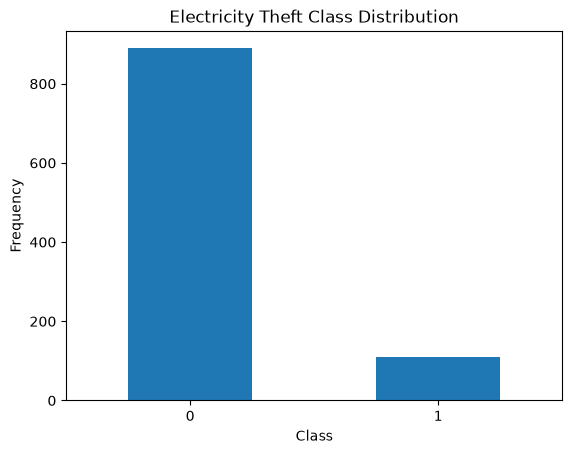

In [8]:
count_classes = pd.value_counts(data['Theft'], sort=True)

count_classes.plot(kind='bar', rot=0)
plt.title('Electricity Theft Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [9]:
theft = data[data['Theft'] == 1]
normal = data[data['Theft'] == 0]

print("Theft Cases :", len(theft))
print("Normal Cases :", len(normal))

Theft Cases : 111
Normal Cases : 889


In [11]:
theft.Avg_Monthly_Units.describe()

count    111.000000
mean     247.110541
std       90.474015
min       40.000000
25%      184.960000
50%      241.740000
75%      311.250000
max      481.840000
Name: Avg_Monthly_Units, dtype: float64

In [12]:
normal.Avg_Monthly_Units.describe()

count    889.000000
mean     259.183363
std       88.956216
min       40.000000
25%      198.490000
50%      260.060000
75%      317.980000
max      526.850000
Name: Avg_Monthly_Units, dtype: float64

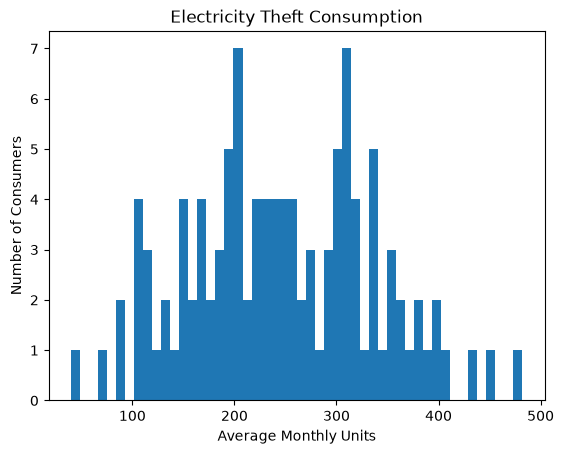

In [13]:
plt.hist(theft.Avg_Monthly_Units, bins=50)

plt.title('Electricity Theft Consumption')
plt.xlabel('Average Monthly Units')
plt.ylabel('Number of Consumers')

plt.show()

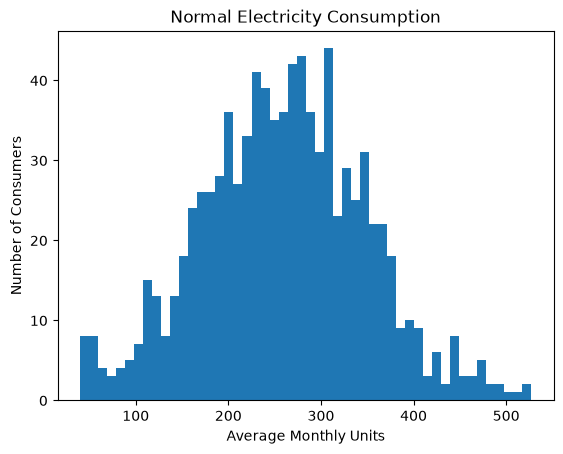

In [14]:
plt.hist(normal.Avg_Monthly_Units, bins=50)

plt.title('Normal Electricity Consumption')
plt.xlabel('Average Monthly Units')
plt.ylabel('Number of Consumers')

plt.show()

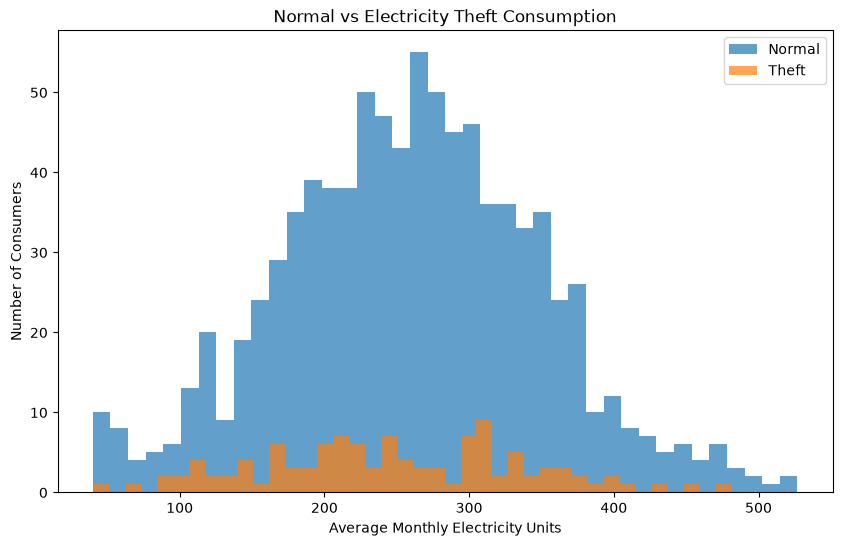

In [15]:
plt.figure(figsize=(10,6))

plt.hist(normal.Avg_Monthly_Units, bins=40, alpha=0.7, label='Normal')
plt.hist(theft.Avg_Monthly_Units, bins=40, alpha=0.7, label='Theft')

plt.title('Normal vs Electricity Theft Consumption')
plt.xlabel('Average Monthly Electricity Units')
plt.ylabel('Number of Consumers')
plt.legend()

plt.show()

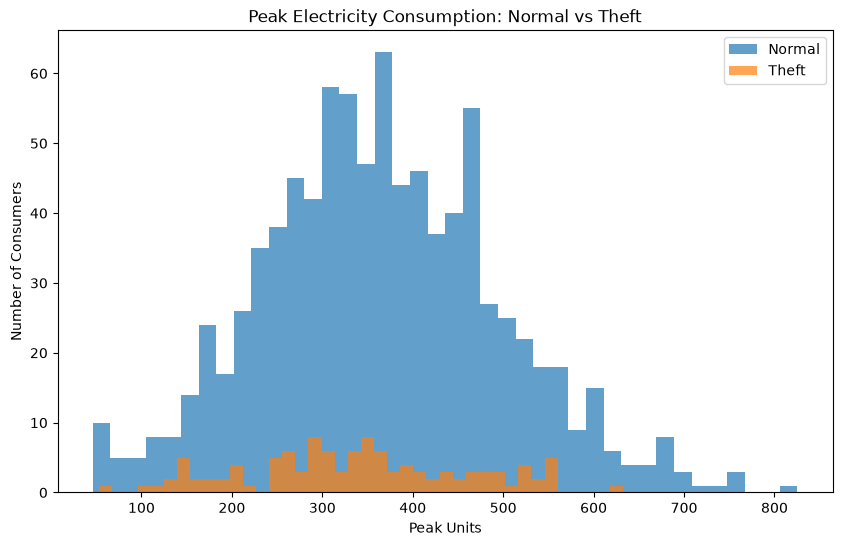

In [16]:
plt.figure(figsize=(10,6))

plt.hist(normal.Peak_Units, bins=40, alpha=0.7, label='Normal')
plt.hist(theft.Peak_Units, bins=40, alpha=0.7, label='Theft')

plt.title('Peak Electricity Consumption: Normal vs Theft')
plt.xlabel('Peak Units')
plt.ylabel('Number of Consumers')
plt.legend()

plt.show()

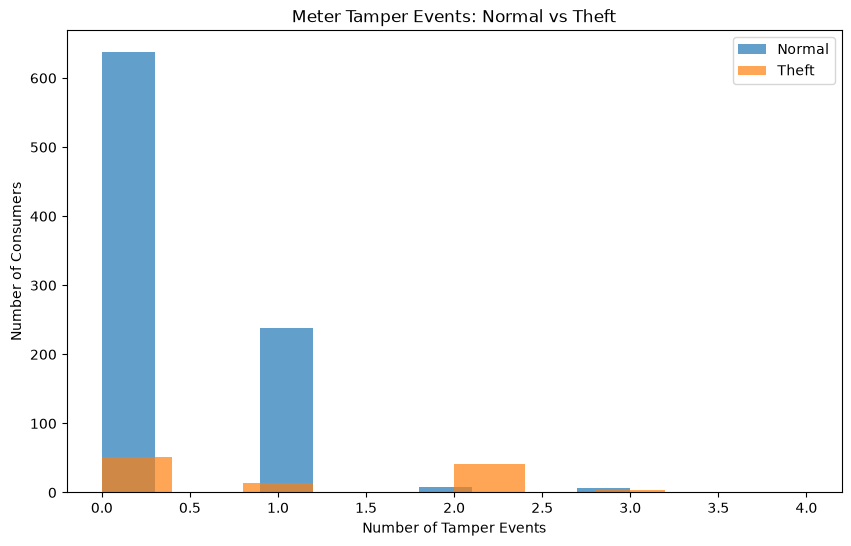

In [17]:
plt.figure(figsize=(10,6))

plt.hist(normal.Tamper_Events, bins=10, alpha=0.7, label='Normal')
plt.hist(theft.Tamper_Events, bins=10, alpha=0.7, label='Theft')

plt.title('Meter Tamper Events: Normal vs Theft')
plt.xlabel('Number of Tamper Events')
plt.ylabel('Number of Consumers')
plt.legend()

plt.show()

In [18]:
outlier_fraction = len(theft) / float(len(normal))

print("Outlier Fraction :", outlier_fraction)
print("Theft Cases :", len(theft))
print("Normal Cases :", len(normal))

Outlier Fraction : 0.12485939257592801
Theft Cases : 111
Normal Cases : 889


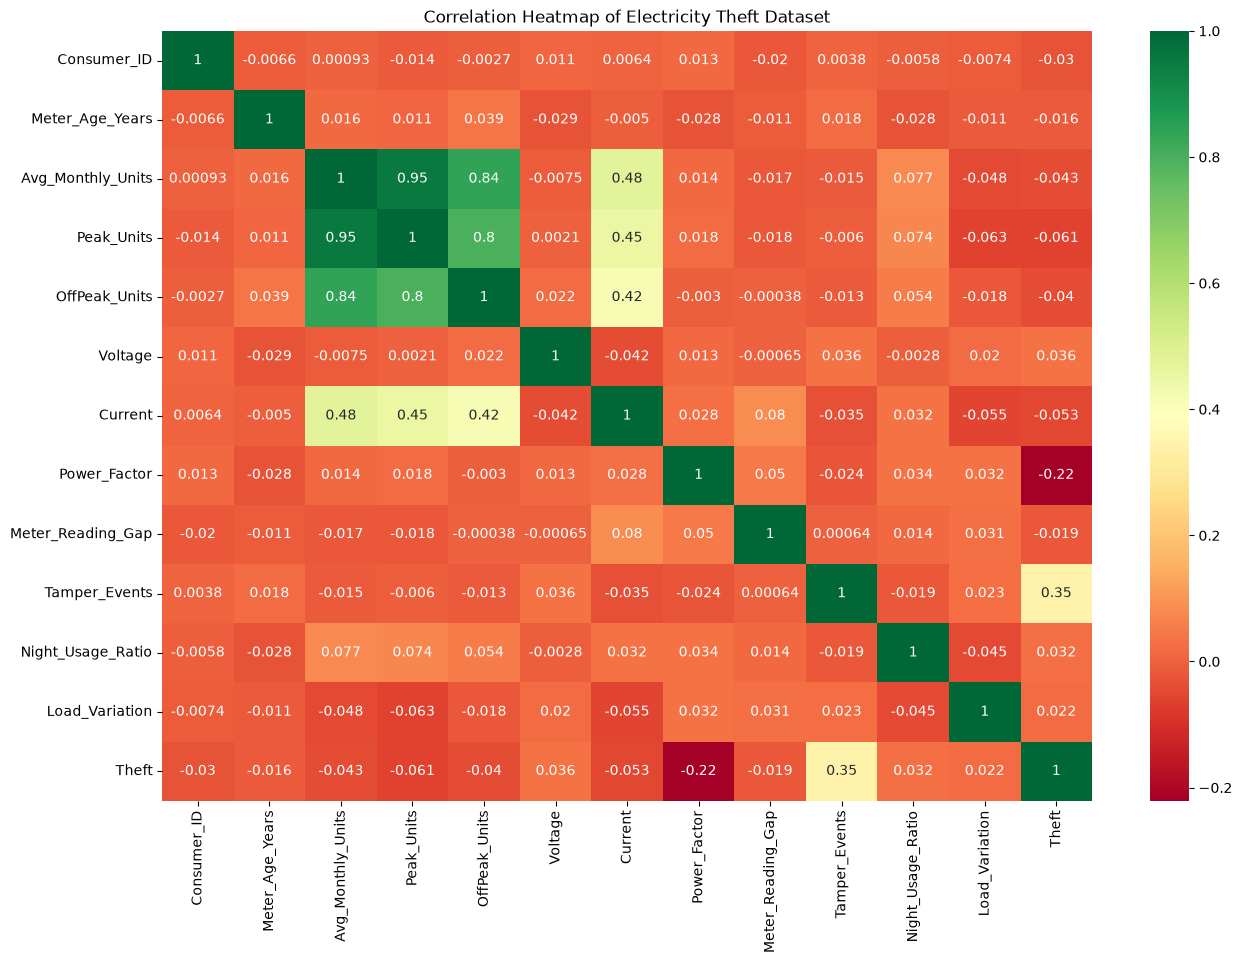

In [19]:
corrmat = data.corr(numeric_only=True)

plt.figure(figsize=(15,10))

sns.heatmap(
    corrmat,
    annot=True,
    cmap="RdYlGn"
)

plt.title("Correlation Heatmap of Electricity Theft Dataset")
plt.show()

In [20]:
columns = data.columns.tolist()

# Remove target column
columns = [c for c in columns if c != "Theft"]

# Input features
X = data[columns]

# Target
Y = data["Theft"]

print("X Shape :", X.shape)
print("Y Shape :", Y.shape)

X Shape : (1000, 12)
Y Shape : (1000,)


In [21]:
columns = data.columns.tolist()

columns = [
    c for c in columns
    if c not in ["Theft", "Consumer_ID"]
]

X = data[columns]
Y = data["Theft"]

print("X Shape :", X.shape)
print("Y Shape :", Y.shape)

X Shape : (1000, 11)
Y Shape : (1000,)


In [22]:
isolation_forest = IsolationForest(
    n_estimators=100,
    max_samples=len(X),
    contamination=outlier_fraction,
    random_state=42,
    verbose=0
)

isolation_forest.fit(X)

,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",1000
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.12485939257592801
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [23]:
y_pred_if = isolation_forest.predict(X)

# Convert predictions:
# 1  → Normal (0)
# -1 → Theft (1)

y_pred_if[y_pred_if == 1] = 0
y_pred_if[y_pred_if == -1] = 1

In [24]:
y_pred_if = isolation_forest.predict(X)

# Convert predictions:
# 1  → Normal (0)
# -1 → Theft (1)

y_pred_if[y_pred_if == 1] = 0
y_pred_if[y_pred_if == -1] = 1

In [25]:
print("Detected Theft Cases :", sum(y_pred_if == 1))
print("Detected Normal Cases :", sum(y_pred_if == 0))

Detected Theft Cases : 125
Detected Normal Cases : 875


In [26]:
accuracy_if = accuracy_score(Y, y_pred_if)

print("Isolation Forest Accuracy :", accuracy_if)

Isolation Forest Accuracy : 0.822


In [27]:
print("Isolation Forest Classification Report:")
print(classification_report(Y, y_pred_if))

Isolation Forest Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       889
           1       0.23      0.26      0.25       111

    accuracy                           0.82      1000
   macro avg       0.57      0.58      0.57      1000
weighted avg       0.83      0.82      0.83      1000



In [28]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    algorithm='auto',
    leaf_size=30,
    metric='minkowski',
    p=2,
    contamination=outlier_fraction
)

y_pred_lof = lof.fit_predict(X)

In [29]:
y_pred_lof[y_pred_lof == 1] = 0
y_pred_lof[y_pred_lof == -1] = 1

In [30]:
print("LOF Predictions:")
print(y_pred_lof)

print("Detected Theft Cases :", sum(y_pred_lof == 1))
print("Detected Normal Cases :", sum(y_pred_lof == 0))

LOF Predictions:
[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0
 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1
 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0
 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0
 0 0 0 0

In [31]:
accuracy_lof = accuracy_score(Y, y_pred_lof)

print("Local Outlier Factor Accuracy :", accuracy_lof)

Local Outlier Factor Accuracy : 0.796


In [32]:
print("Local Outlier Factor Classification Report:")
print(classification_report(Y, y_pred_lof))

Local Outlier Factor Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       889
           1       0.13      0.14      0.14       111

    accuracy                           0.80      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.81      0.80      0.80      1000



In [33]:
accuracy_lof = accuracy_score(Y, y_pred_lof)

print("Local Outlier Factor")
print("Accuracy Score :", accuracy_lof)

print("\nClassification Report:")
print(classification_report(Y, y_pred_lof))

Local Outlier Factor
Accuracy Score : 0.796

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       889
           1       0.13      0.14      0.14       111

    accuracy                           0.80      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.81      0.80      0.80      1000



In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

if_precision = precision_score(Y, y_pred_if, zero_division=0)
if_recall = recall_score(Y, y_pred_if, zero_division=0)
if_f1 = f1_score(Y, y_pred_if, zero_division=0)

lof_precision = precision_score(Y, y_pred_lof, zero_division=0)
lof_recall = recall_score(Y, y_pred_lof, zero_division=0)
lof_f1 = f1_score(Y, y_pred_lof, zero_division=0)

In [35]:
comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Local Outlier Factor"],
    "Accuracy": [accuracy_if, accuracy_lof],
    "Precision": [if_precision, lof_precision],
    "Recall": [if_recall, lof_recall],
    "F1-Score": [if_f1, lof_f1]
})

print(comparison)

                  Model  Accuracy  Precision    Recall  F1-Score
0      Isolation Forest     0.822      0.232  0.261261  0.245763
1  Local Outlier Factor     0.796      0.128  0.144144  0.135593


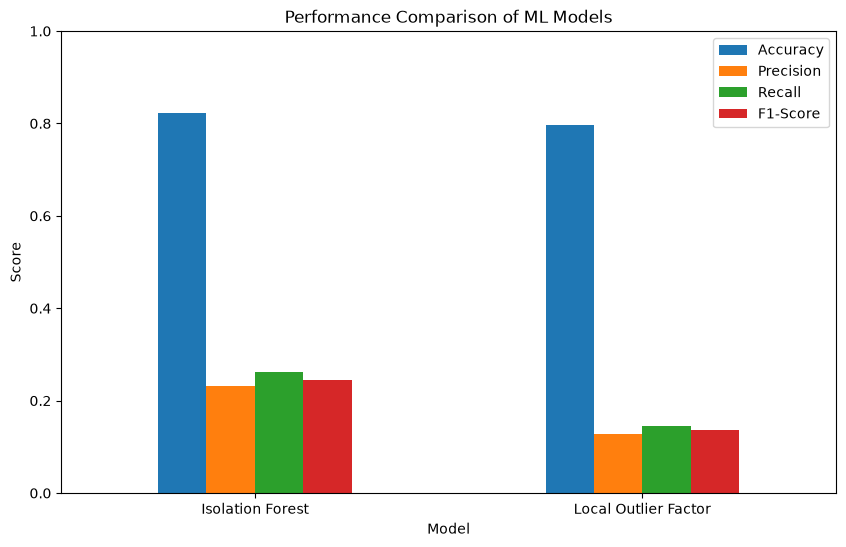

In [36]:
comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of ML Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

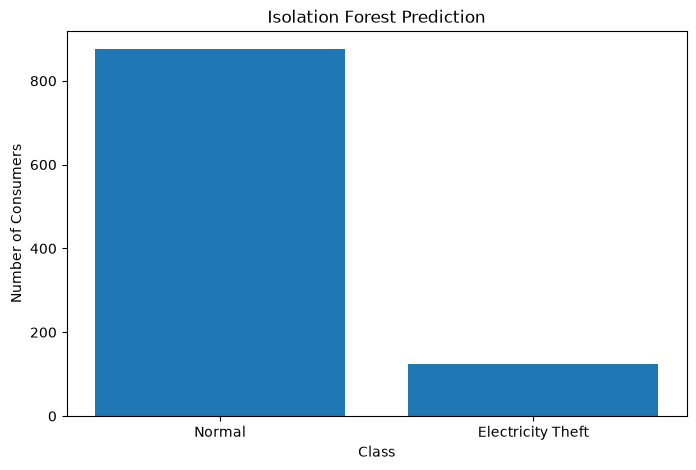

In [37]:
prediction_counts = pd.Series(y_pred_if).value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    ["Normal", "Electricity Theft"],
    prediction_counts.values
)

plt.title("Isolation Forest Prediction")
plt.xlabel("Class")
plt.ylabel("Number of Consumers")

plt.show()

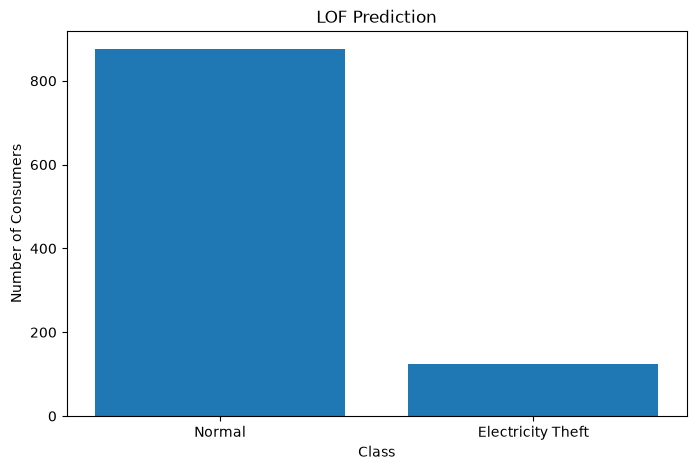

In [38]:
prediction_counts_lof = pd.Series(y_pred_lof).value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    ["Normal", "Electricity Theft"],
    prediction_counts_lof.values
)

plt.title("LOF Prediction")
plt.xlabel("Class")
plt.ylabel("Number of Consumers")

plt.show()

In [39]:
comparison_data = pd.DataFrame({
    "Actual": Y,
    "Isolation_Forest": y_pred_if,
    "LOF": y_pred_lof
})

print(comparison_data.head(20))

    Actual  Isolation_Forest  LOF
0        0                 0    0
1        1                 0    0
2        0                 1    0
3        0                 0    0
4        1                 1    0
5        0                 0    0
6        0                 0    0
7        1                 0    0
8        0                 0    0
9        0                 1    0
10       0                 0    0
11       0                 1    1
12       0                 0    0
13       0                 0    0
14       1                 0    0
15       0                 0    0
16       0                 0    0
17       0                 0    0
18       0                 0    1
19       0                 0    0


In [40]:
results = pd.DataFrame({
    "Algorithm": ["Isolation Forest", "Local Outlier Factor"],
    "Accuracy": [accuracy_if, accuracy_lof],
    "Precision": [if_precision, lof_precision],
    "Recall": [if_recall, lof_recall],
    "F1-Score": [if_f1, lof_f1]
})

print(results)

              Algorithm  Accuracy  Precision    Recall  F1-Score
0      Isolation Forest     0.822      0.232  0.261261  0.245763
1  Local Outlier Factor     0.796      0.128  0.144144  0.135593


In [41]:
print("\nFINAL MODEL PERFORMANCE")
print("=" * 60)

for i in range(len(results)):
    print("\nAlgorithm :", results.iloc[i]["Algorithm"])
    print("Accuracy  :", round(results.iloc[i]["Accuracy"], 4))
    print("Precision :", round(results.iloc[i]["Precision"], 4))
    print("Recall    :", round(results.iloc[i]["Recall"], 4))
    print("F1-Score  :", round(results.iloc[i]["F1-Score"], 4))


FINAL MODEL PERFORMANCE

Algorithm : Isolation Forest
Accuracy  : 0.822
Precision : 0.232
Recall    : 0.2613
F1-Score  : 0.2458

Algorithm : Local Outlier Factor
Accuracy  : 0.796
Precision : 0.128
Recall    : 0.1441
F1-Score  : 0.1356
